# Detector de Correos Phishing con Naive Bayes

## Actividad 3 - Machine Learning

### Integrantes
- Nombre 1
- Nombre 2
- Nombre 3

Este proyecto tiene como objetivo detectar correos electrónicos phishing utilizando técnicas de procesamiento de lenguaje natural (NLP) y el algoritmo Naive Bayes.

El modelo analiza el contenido de los correos y determina si son legítimos o potencialmente fraudulentos.

# 1. Carga y exploración de datos

En esta sección se importan las librerías necesarias para el análisis de datos, visualización y entrenamiento del modelo.

In [77]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de gráficos
plt.style.use('default')

## Carga del dataset

Se carga el dataset CEAS_08.csv, el cual contiene correos electrónicos clasificados como phishing o legítimos.

In [78]:
# Cargar dataset
df = pd.read_csv('../data/raw/CEAS_08.csv')

# Mostrar primeras filas
df.head()

,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


## Información general del dataset

Se analiza:
- cantidad de registros
- tipos de datos
- posibles valores nulos
- estructura general del dataset

In [79]:
# Mostrar información general
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 39154 entries, 0 to 39153
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   sender    39154 non-null  str  
 1   receiver  38692 non-null  str  
 2   date      39154 non-null  str  
 3   subject   39126 non-null  str  
 4   body      39154 non-null  str  
 5   label     39154 non-null  int64
 6   urls      39154 non-null  int64
dtypes: int64(2), str(5)
memory usage: 66.3 MB
None


In [80]:
# Mostrar estadísticas descriptivas
print(df.describe())

              label         urls
count  39154.000000  39154.00000
mean       0.557848      0.66997
std        0.496649      0.47023
min        0.000000      0.00000
25%        0.000000      0.00000
50%        1.000000      1.00000
75%        1.000000      1.00000
max        1.000000      1.00000


# 2. EDA (Análisis Exploratorio)

En esta etapa se exploran las características principales del dataset mediante gráficos y análisis estadístico.

## Valores nulos

Se verifica si existen datos faltantes que puedan afectar el entrenamiento del modelo.

In [81]:
# Contar valores nulos
df.isnull().sum()

sender        0
receiver    462
date          0
subject      28
body          0
label         0
urls          0
dtype: int64

## Distribución de clases

En este gráfico se muestra la cantidad de correos legítimos y correos phishing presentes en el dataset.

- 0 = Correo legítimo
- 1 = Correo phishing

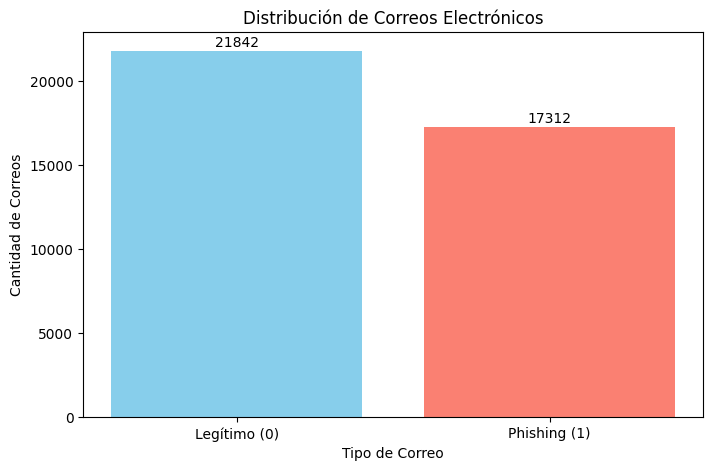

In [82]:
# Contar correos por clase
class_counts = df['label'].value_counts()

# Crear figura
plt.figure(figsize=(8,5))

# Crear gráfico de barras
plt.bar(
    ['Legítimo (0)', 'Phishing (1)'],
    class_counts.values,
    color=['skyblue', 'salmon']
)

# Título
plt.title("Distribución de Correos Electrónicos")

# Nombre eje X
plt.xlabel("Tipo de Correo")

# Nombre eje Y
plt.ylabel("Cantidad de Correos")

# Mostrar valores encima de las barras
for i, value in enumerate(class_counts.values):
    plt.text(i, value + 200, str(value), ha='center')

# Mostrar gráfico
plt.show()

## Longitud de los correos electrónicos

Se analiza la cantidad de caracteres presentes en cada correo para identificar diferencias entre correos legítimos y phishing.

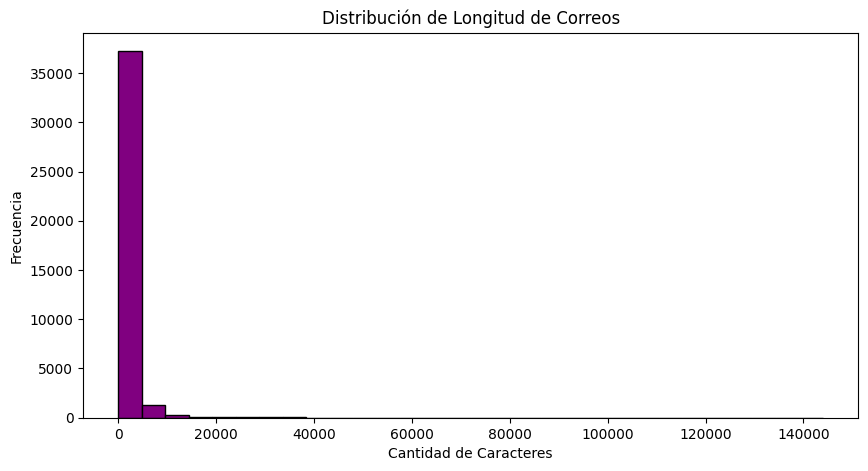

In [83]:
# Crear columna con longitud del texto
df['text_length'] = df['body'].apply(len)

# Crear figura
plt.figure(figsize=(10,5))

# Crear histograma
plt.hist(
    df['text_length'],
    bins=30,
    color='purple',
    edgecolor='black'
)

# Título
plt.title("Distribución de Longitud de Correos")

# Eje X
plt.xlabel("Cantidad de Caracteres")

# Eje Y
plt.ylabel("Frecuencia")

# Mostrar gráfico
plt.show()

## Correos más largos y más cortos

Se revisan ejemplos extremos para identificar posibles anomalías en los datos.

In [84]:
# Mostrar correos más largos
df[['subject', 'text_length']].sort_values(
    by='text_length',
    ascending=False
).head()

,subject,text_length
3634,Buzz Alert! Ten things the cool kids are talki...,143996
5290,"ietf-dkim Digest, Vol 107, Issue 7",123029
4363,[R] P values in non linear regression and sing...,96498
9122,[opensuse] sed - howto strip from character to...,87849
2751,[clamav-virusdb] Update (daily: 5778),83725


## Correlación entre variables numéricas

El mapa de calor permite identificar relaciones entre variables numéricas del dataset.

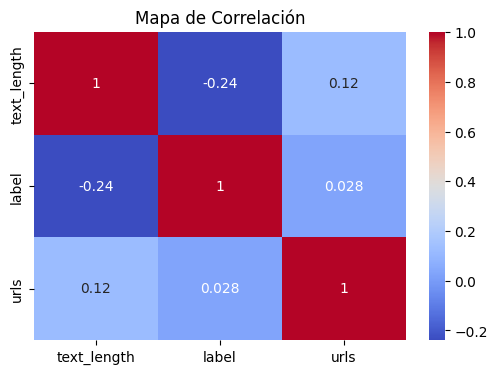

In [85]:
# Calcular correlación
correlation = df[['text_length', 'label', 'urls']].corr()

# Crear figura
plt.figure(figsize=(6,4))

# Crear heatmap
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

# Título
plt.title("Mapa de Correlación")

# Mostrar gráfico
plt.show()

## Detección de valores atípicos (Outliers)

El siguiente gráfico permite identificar correos con tamaños inusualmente grandes o pequeños.

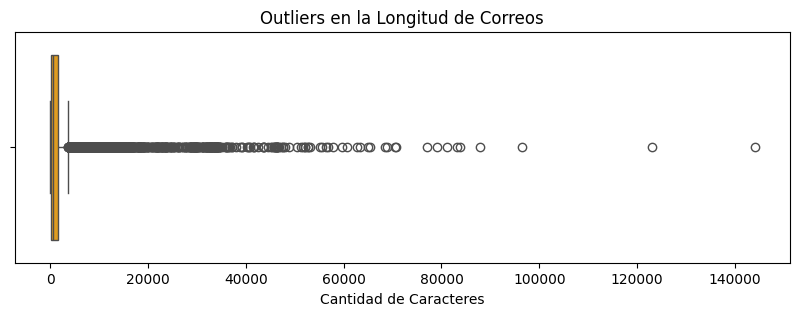

In [86]:
# Crear figura
plt.figure(figsize=(10,3))

# Crear boxplot
sns.boxplot(
    x=df['text_length'],
    color='orange'
)

# Título
plt.title("Outliers en la Longitud de Correos")

# Nombre eje X
plt.xlabel("Cantidad de Caracteres")

# Mostrar gráfico
plt.show()

# 3. Preprocesamiento

En esta sección se preparan los datos para el entrenamiento del modelo.

## Limpieza de datos

Se eliminan registros con valores nulos para evitar errores durante el entrenamiento.

In [87]:
# Eliminar valores nulos
df = df.dropna()

## Selección de variables

La variable independiente será el contenido del correo y la variable objetivo será la clasificación del correo.

In [88]:
# Combinar asunto y cuerpo del correo
df['text'] = df['subject'] + " " + df['body']

# Variable independiente
X = df['text']

# Variable dependiente
y = df['label']

##Limpieza del texto

Se realiza una limpieza básica del contenido de los correos electrónicos para eliminar información innecesaria.

El proceso incluye:
- conversión a minúsculas
- eliminación de enlaces
- eliminación de caracteres especiales

Esto ayuda a mejorar la calidad de los datos utilizados por el modelo.

In [89]:
import re

# Función para limpiar texto
def clean_text(text):

    # Convertir texto a minúsculas
    text = text.lower()

    # Eliminar enlaces
    text = re.sub(r'http\S+', '', text)

    # Eliminar caracteres especiales
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text

# Aplicar limpieza
X = X.apply(clean_text)

## Vectorización TF-IDF

Los algoritmos de Machine Learning no pueden trabajar directamente con texto.

Por ello se utiliza TF-IDF para convertir palabras en valores numéricos.

In [90]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Crear vectorizador TF-IDF mejorado
vectorizer = TfidfVectorizer(

    # Eliminar palabras comunes en inglés
    stop_words='english',

    # Utilizar más palabras importantes
    max_features=10000,

    # Utilizar unigramas y bigramas
    ngram_range=(1,2)

)

# Transformar texto
X = vectorizer.fit_transform(X)

# Mostrar dimensiones
print(X.shape)

(38669, 10000)


## División train/test

El dataset se divide en:
- 80% entrenamiento
- 20% pruebas

In [91]:
from sklearn.model_selection import train_test_split

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Mostrar dimensiones
print("Entrenamiento:", X_train.shape)
print("Pruebas:", X_test.shape)

Entrenamiento: (30935, 10000)
Pruebas: (7734, 10000)


# 4. Entrenamiento del Modelo

Se utiliza el algoritmo Naive Bayes para clasificar correos electrónicos.

In [92]:
from sklearn.naive_bayes import MultinomialNB

# Crear modelo Naive Bayes mejorado
model = MultinomialNB(

    # Reducir suavizado
    alpha=0.3

)

# Entrenar modelo
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.3
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


# 5. Evaluación del Modelo

En esta etapa se evalúa el rendimiento del modelo mediante diferentes métricas de clasificación.

In [93]:
# Realizar predicciones
y_pred = model.predict(X_test)

## Accuracy

Mide el porcentaje total de predicciones correctas.

In [94]:
from sklearn.metrics import accuracy_score

# Calcular accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9681923972071373


## Precision

Mide cuántos correos detectados como phishing realmente lo eran.

In [95]:
from sklearn.metrics import precision_score

# Calcular precision
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.9978192391567725


## Recall

Mide cuántos correos phishing fueron detectados correctamente.

In [96]:
from sklearn.metrics import recall_score

# Calcular recall
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.9455797933409874


## Matriz de Confusión

La matriz de confusión permite visualizar aciertos y errores del modelo.

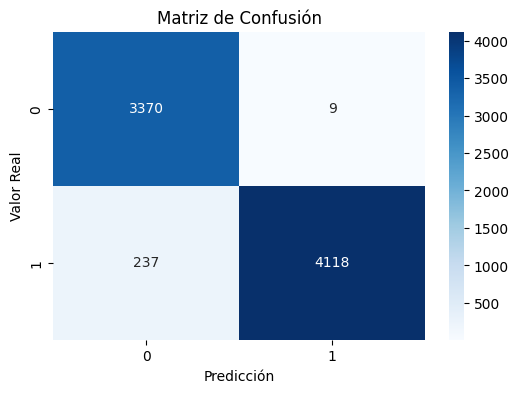

In [97]:
from sklearn.metrics import confusion_matrix

# Crear matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Tamaño del gráfico
plt.figure(figsize=(6,4))

# Crear heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

# Título
plt.title("Matriz de Confusión")

# Eje X
plt.xlabel("Predicción")

# Eje Y
plt.ylabel("Valor Real")

# Mostrar gráfico
plt.show()

## Reporte de clasificación

Se muestran métricas completas del modelo.

In [98]:
from sklearn.metrics import classification_report

# Mostrar reporte
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96      3379
           1       1.00      0.95      0.97      4355

    accuracy                           0.97      7734
   macro avg       0.97      0.97      0.97      7734
weighted avg       0.97      0.97      0.97      7734



# 6. Serialización del Modelo

Finalmente se guarda el modelo entrenado y el vectorizador TF-IDF para utilizarlos posteriormente en la aplicación web.

In [99]:
import joblib

# Guardar modelo actualizado
joblib.dump(model, '../models/modelo.pkl')

# Guardar vectorizador actualizado
joblib.dump(vectorizer, '../models/vectorizer.pkl')

print("Modelo y vectorizador guardados correctamente")

Modelo y vectorizador guardados correctamente
